In [ ]:
%pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Split training data into train and validation sets
x_val = x_train[-5000:].astype("float32")
y_val = y_train[-5000:].reshape(-1)

x_train = x_train[:-5000].astype("float32")
y_train = y_train[:-5000].reshape(-1)

x_test = x_test.astype("float32")

# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Convert labels to one-hot vectors
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test.reshape(-1), 10)

# Build CNN model
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping callback
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1773s 10us/step
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.3416 - loss: 1.8139 - val_accuracy: 0.4530 - val_loss: 1.4720
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4457 - loss: 1.5336 - val_accuracy: 0.5692 - val_loss: 1.2197
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5004 - loss: 1.3950 - val_accuracy: 0.5524 - val_loss: 1.2757
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5405 - loss: 1.2919 - val_accuracy: 0.5618 - val_loss: 1.3057
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5733 - loss: 1.2213 - val_accuracy: 0.6404 - val_loss: 1.0340
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5991 - loss: 1.1546 - val_accuracy: 0.5760 - val_loss: 1.2837
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6101 - loss: 1.1171 - val_accuracy: 0.6902 - val_loss: 0.8733
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━

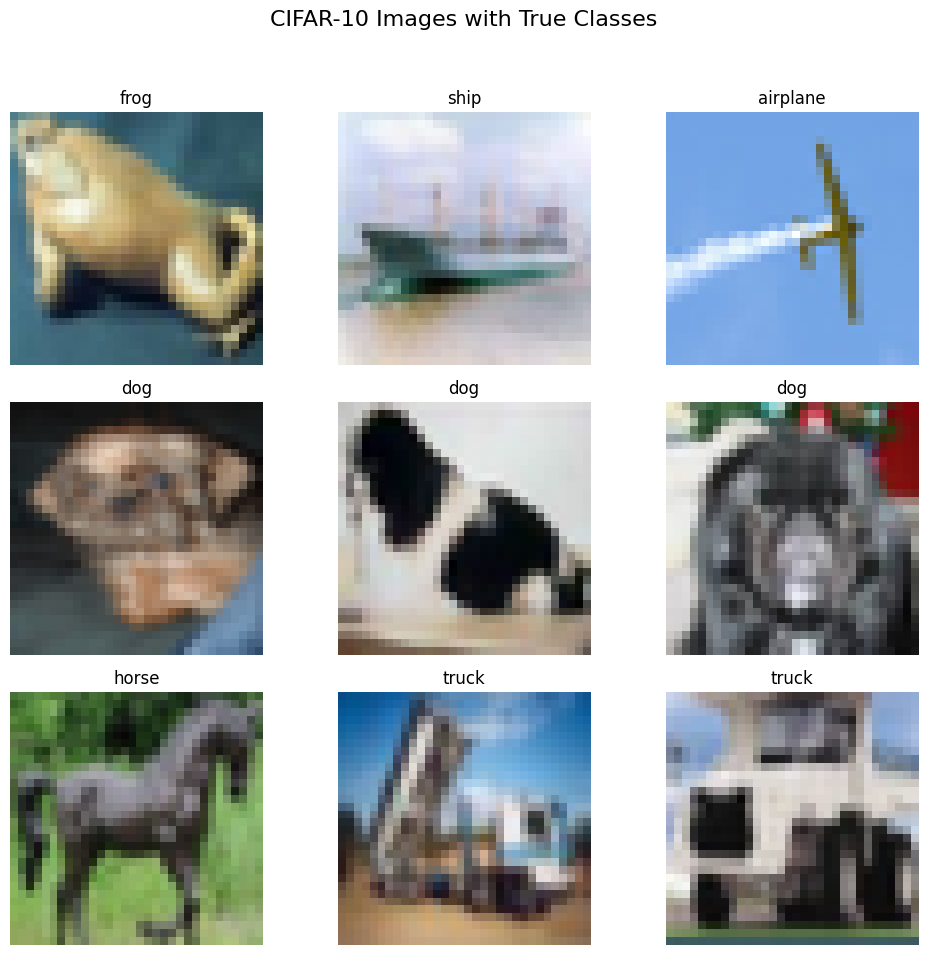

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10 # Load CIFAR-10 specifically for this cell

# Load only the test set for visualization to avoid overwriting existing training data
(_, _), (x_cifar_test, y_cifar_test) = cifar10.load_data()

# Define CIFAR-10 class names
cifar_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalize pixel values to [0, 1] for display
x_cifar_test = x_cifar_test.astype('float32') / 255.0

# Select a few random images from the CIFAR-10 test set
num_images_to_show = 9
random_indices_cifar = np.random.choice(x_cifar_test.shape[0], num_images_to_show, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices_cifar):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_cifar_test[idx]) # CIFAR-10 images are (32, 32, 3)
    plt.title(cifar_class_names[y_cifar_test[idx][0]])
    plt.axis('off')
plt.suptitle('CIFAR-10 Images with True Classes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()